Kent Lin Chan

20202132

Se usó Python 3.14.2

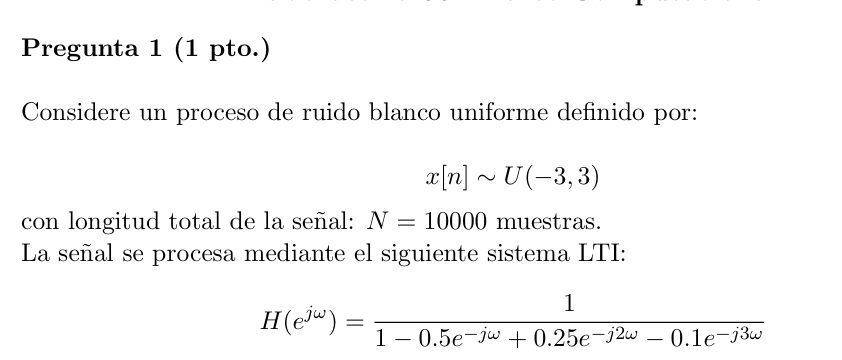

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
%matplotlib inline

np.random.seed(2026)

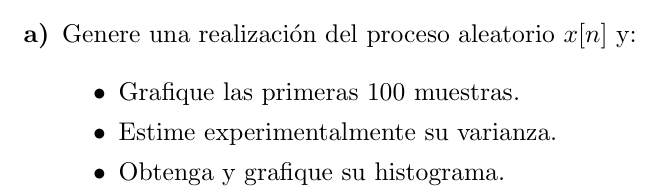

In [2]:
# Parámetros del proceso
N = 10000           # número total de muestras
a = 3

# Generación del ruido blanco uniforme
x = np.random.uniform(-a, a, N)

print(f"Varianza teórica:  sigma^2 = {a**2/3:.4f}")
print(f"Varianza estimada: sigma^2 = {np.var(x):.4f}")

Varianza teórica:  sigma^2 = 3.0000
Varianza estimada: sigma^2 = 2.9934


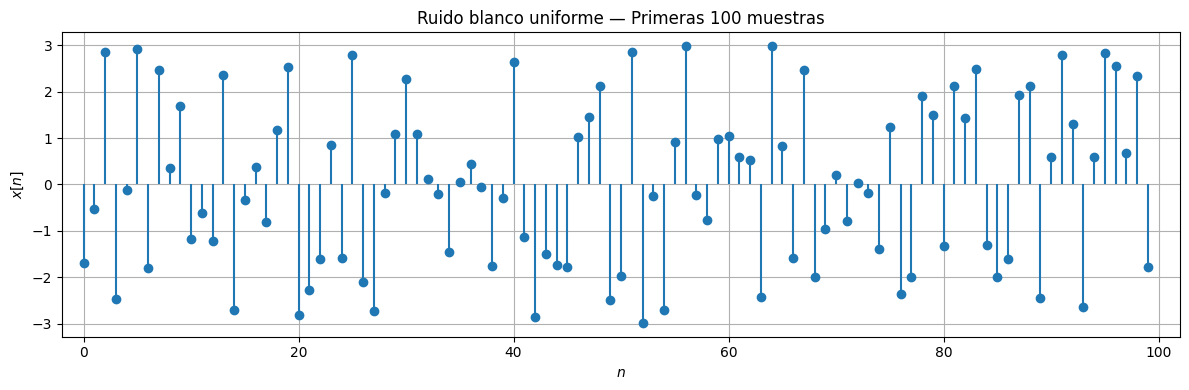

In [3]:
n = np.arange(N)

plt.figure(figsize=[12, 4])
plt.stem(n[:100], x[:100], basefmt=" ")
plt.xlabel('$n$')
plt.ylabel('$x[n]$')
plt.title('Ruido blanco uniforme — Primeras 100 muestras')
plt.grid(True)
plt.xlim([-2, 102])
plt.tight_layout()

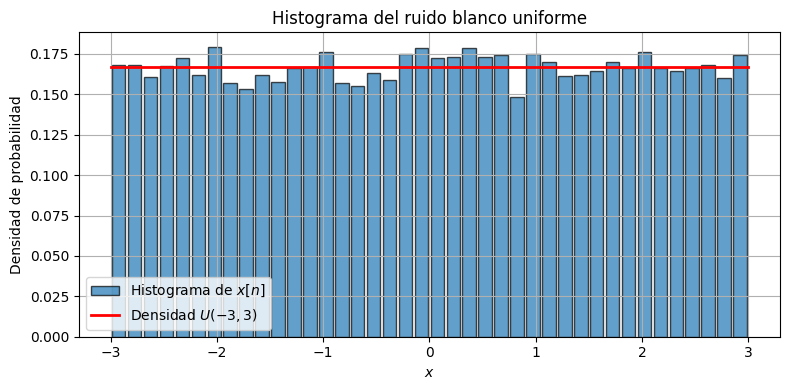

In [4]:
plt.figure(figsize=[8, 4])
plt.hist(x, bins=40, density=True, rwidth=0.85, ec='k', alpha=0.7,
         label='Histograma de $x[n]$')

# Densidad teórica uniforme en [-a, a]
xpdf = np.linspace(-a, a, 400)
ypdf = 1 / (2 * a) * np.ones_like(xpdf)
plt.plot(xpdf, ypdf, 'r', linewidth=2, label=f'Densidad $U(-{a}, {a})$')

plt.xlabel('$x$')
plt.ylabel('Densidad de probabilidad')
plt.title('Histograma del ruido blanco uniforme')
plt.legend()
plt.grid(True)
plt.tight_layout()

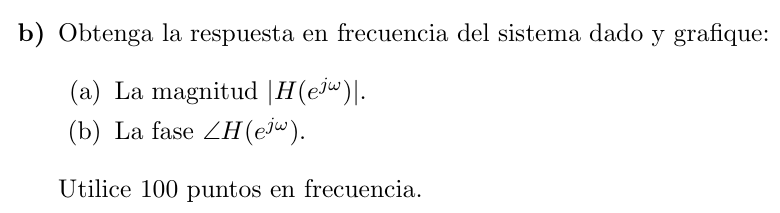

In [5]:
# Coeficientes del sistema LTI
b = np.array([1.0])                              # numerador
a_lti = np.array([1.0, -0.5, 0.25, -0.1])        # denominador

# 100 puntos en frecuencia
N_freq = 100
w, H = signal.freqz(b, a_lti, worN=N_freq)

# Conversión a radianes normalizados y a Hz (frecuencia normalizada)
w_norm = w / np.pi                              # 0 .. 1 (1 -> pi rad)

mag = np.abs(H)
phase = np.unwrap(np.angle(H))                   # fase desenvuelta

print(f"Número de puntos en frecuencia: {N_freq}")

Número de puntos en frecuencia: 100


<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\kentj\AppData\Local\Temp\ipykernel_18484\2434293440.py:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  axes[0].set_xlabel('Frecuencia normalizada ($\\omega / \pi$)')
C:\Users\kentj\AppData\Local\Temp\ipykernel_18484\2434293440.py:13: SyntaxWarning: "\p" is an invalid escap

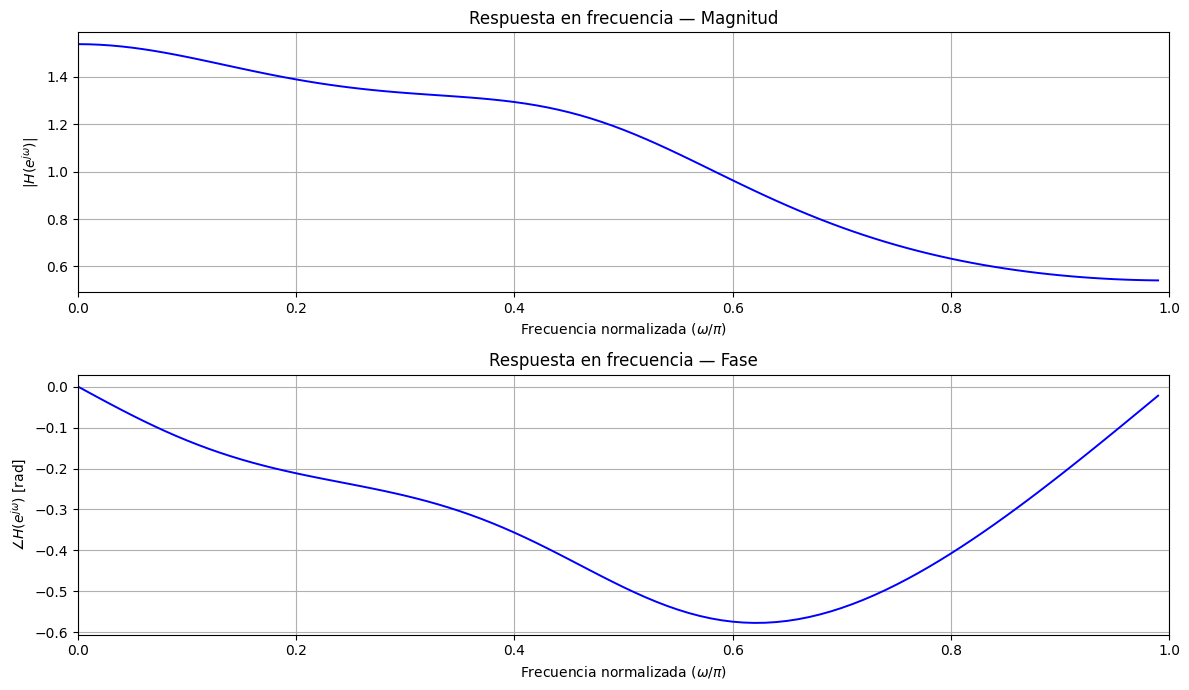

In [6]:
fig, axes = plt.subplots(2, 1, figsize=[12, 7])

# Magnitud
axes[0].plot(w_norm, mag, 'b', linewidth=1.4)
axes[0].set_xlabel('Frecuencia normalizada ($\\omega / \pi$)')
axes[0].set_ylabel('$|H(e^{j\\omega})|$')
axes[0].set_title('Respuesta en frecuencia — Magnitud')
axes[0].grid(True)
axes[0].set_xlim([0, 1])

# Fase
axes[1].plot(w_norm, phase, 'b', linewidth=1.4)
axes[1].set_xlabel('Frecuencia normalizada ($\\omega / \pi$)')
axes[1].set_ylabel('$\\angle H(e^{j\\omega})$ [rad]')
axes[1].set_title('Respuesta en frecuencia — Fase')
axes[1].grid(True)
axes[1].set_xlim([0, 1])

plt.tight_layout()

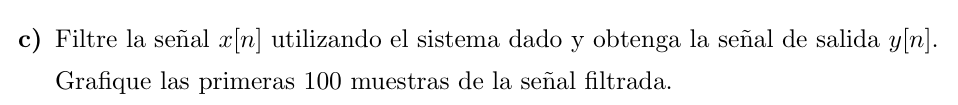

In [7]:
# Filtrado de la señal de ruido blanco
y = signal.lfilter(b, a_lti, x)

print(f"Número de muestras: x[n]={len(x)}, y[n]={len(y)}")

Número de muestras: x[n]=10000, y[n]=10000


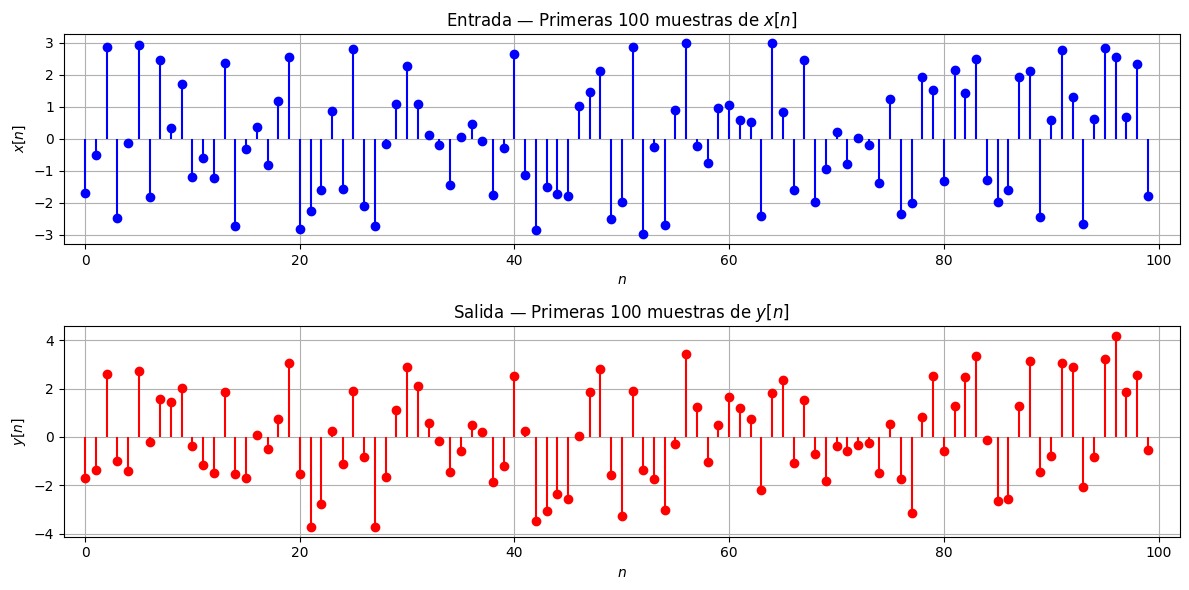

In [8]:
fig, axes = plt.subplots(2, 1, figsize=[12, 6])

axes[0].stem(n[:100], x[:100], basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('$n$')
axes[0].set_ylabel('$x[n]$')
axes[0].set_title('Entrada — Primeras 100 muestras de $x[n]$')
axes[0].grid(True)
axes[0].set_xlim([-2, 102])

axes[1].stem(n[:100], y[:100], basefmt=" ", linefmt='r-', markerfmt='ro')
axes[1].set_xlabel('$n$')
axes[1].set_ylabel('$y[n]$')
axes[1].set_title('Salida — Primeras 100 muestras de $y[n]$')
axes[1].grid(True)
axes[1].set_xlim([-2, 102])

plt.tight_layout()

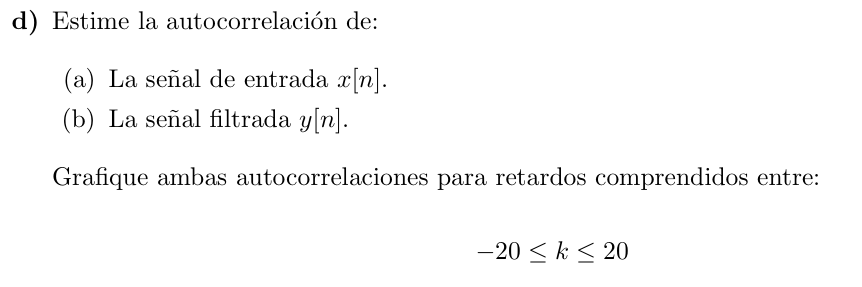

In [9]:
def autocorr(signal_vec, kmax):
    """Autocorrelación para retardos en [-kmax, kmax]."""
    N = len(signal_vec)
    r = np.zeros(2 * kmax + 1)
    ks = np.arange(-kmax, kmax + 1)
    for i, k in enumerate(ks):
        if k >= 0:
             r[i] = np.sum(signal_vec[:N - k] * signal_vec[k:]) / N
        else:
             r[i] = np.sum(signal_vec[-k:] * signal_vec[:N + k]) / N
    return ks, r

kmax = 20
ks, rxx = autocorr(x, kmax)
_,  ryy = autocorr(y, kmax)

print(f"r_xx[0]  = {rxx[kmax]:.4f}   (varianza de x)")
print(f"r_yy[0]  = {ryy[kmax]:.4f}   (varianza de y)")

r_xx[0]  = 2.9935   (varianza de x)
r_yy[0]  = 3.7247   (varianza de y)


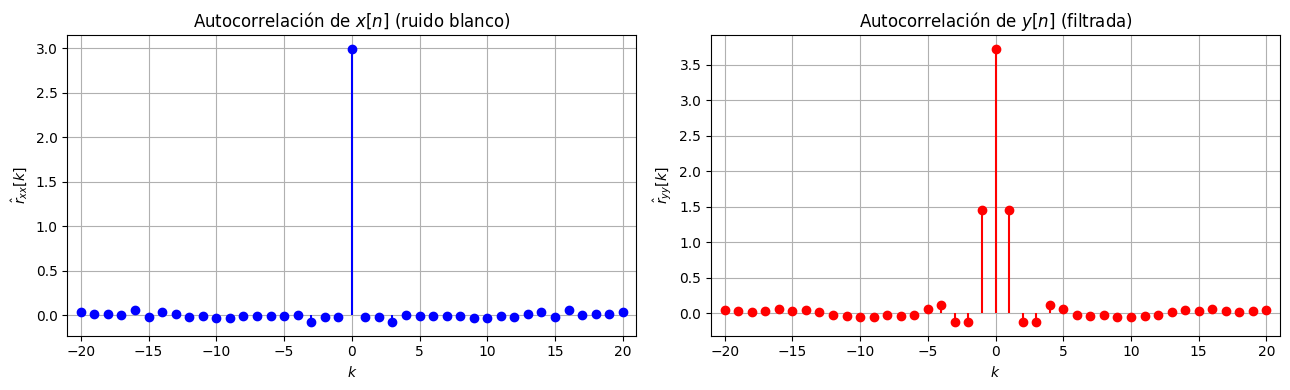

In [10]:
fig, axes = plt.subplots(1, 2, figsize=[13, 4])

# Autocorrelación de x[n]
axes[0].stem(ks, rxx, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('$k$')
axes[0].set_ylabel('$\\hat{r}_{xx}[k]$')
axes[0].set_title('Autocorrelación de $x[n]$ (ruido blanco)')
axes[0].grid(True)
axes[0].set_xlim([-kmax - 1, kmax + 1])

# Autocorrelación de y[n]
axes[1].stem(ks, ryy, basefmt=" ", linefmt='r-', markerfmt='ro')
axes[1].set_xlabel('$k$')
axes[1].set_ylabel('$\\hat{r}_{yy}[k]$')
axes[1].set_title('Autocorrelación de $y[n]$ (filtrada)')
axes[1].grid(True)
axes[1].set_xlim([-kmax - 1, kmax + 1])

plt.tight_layout()

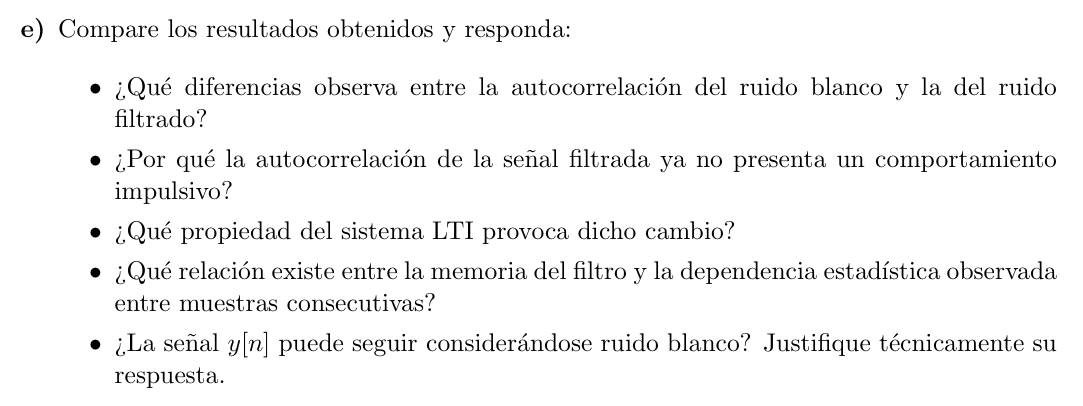

- La autocorrelación del ruido blanco $x[n]$ es esencialmente un impulso en $k = 0$, reflejando la independencia estadística entre muestras.
- La autocorrelación de la señal filtrada $y[n]$ toma valores significativos para $k \neq 0$ y decae gradualmente, lo que indica que las muestras de $y[n]$ ya no son independientes.
- Esto se debe a que el sistema LTI, al tener memoria, combina linealmente varias muestras de la entrada; así, la salida depende de un bloque de valores pasados de $x[n]$.
- A más coeficientes del filtro, mayor es el rango de retardos $k$ para los que $\hat{r}_{yy}[k]$ es distinto de cero.
- La señal $y[n]$ no puede considerarse ruido blanco, pues su autocorrelación no es impulsiva: existe correlación entre muestras consecutivas y, por tanto, dependencia estadística.

---

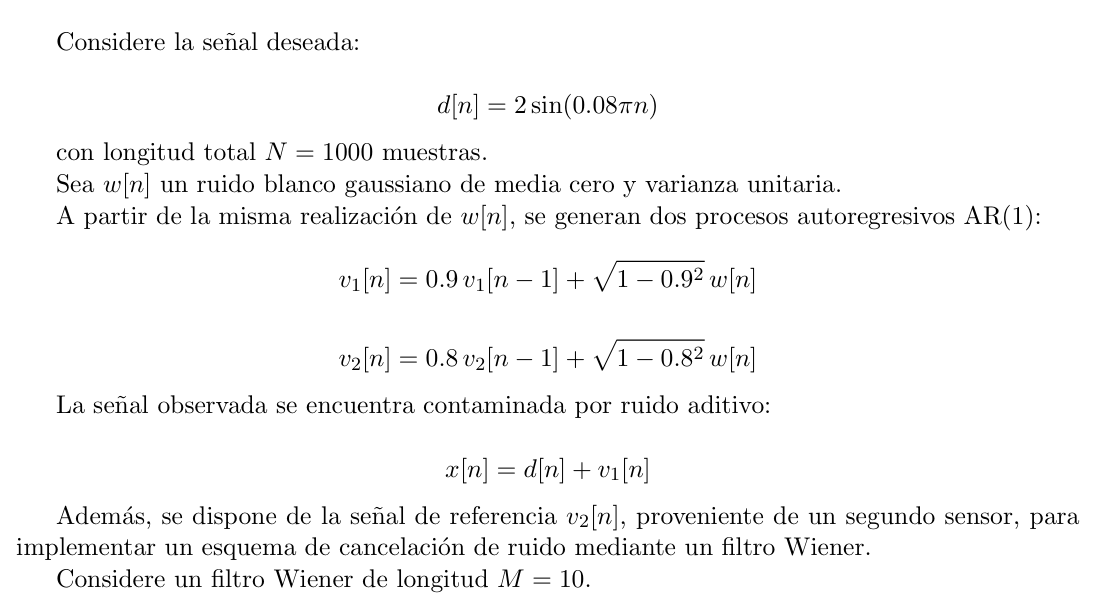


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
%matplotlib inline

np.random.seed(2026)

# Parámetros del problema
N  = 1000         # longitud total
M  = 10           # longitud del filtro Wiener
a1 = 0.9          # coeficiente AR(1) de v1
a2 = 0.8          # coeficiente AR(1) de v2

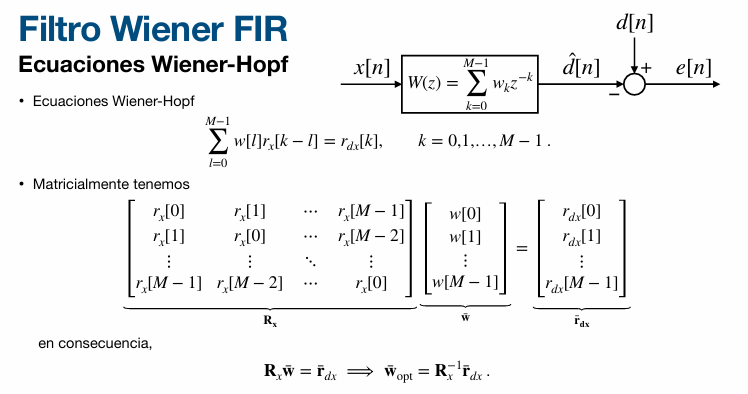

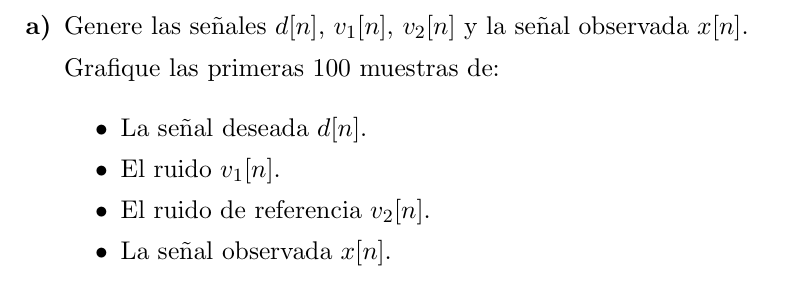

In [12]:
n = np.arange(N)

# Señal deseada
d = 2 * np.sin(0.08 * np.pi * n)

# Ruido blanco gaussiano w[n] ~ N(0, 1)
w = np.random.randn(N)

# Procesos AR(1)
v1 = signal.lfilter([np.sqrt(1 - a1**2)], [1, -a1], w)
v2 = signal.lfilter([np.sqrt(1 - a2**2)], [1, -a2], w)

# Señal observada
x = d + v1

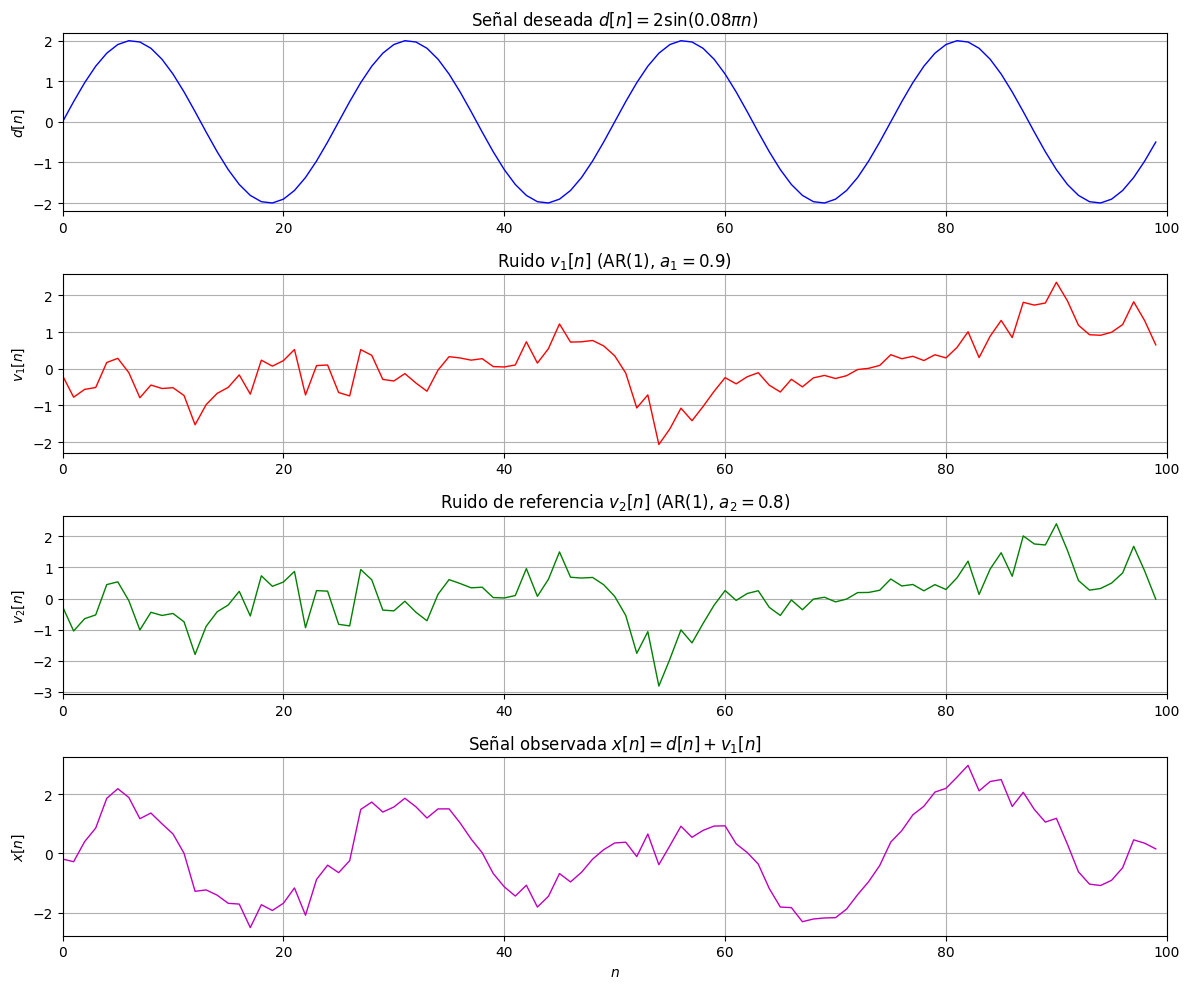

In [13]:
fig, axes = plt.subplots(4, 1, figsize=[12, 10])

axes[0].plot(n[:100], d[:100], 'b', linewidth=1.0)
axes[0].set_ylabel('$d[n]$')
axes[0].set_title('Señal deseada $d[n] = 2 \\sin(0.08 \\pi n)$')
axes[0].grid(True)
axes[0].set_xlim([0, 100])

axes[1].plot(n[:100], v1[:100], 'r', linewidth=1.0)
axes[1].set_ylabel('$v_1[n]$')
axes[1].set_title('Ruido $v_1[n]$ (AR(1), $a_1 = 0.9$)')
axes[1].grid(True)
axes[1].set_xlim([0, 100])

axes[2].plot(n[:100], v2[:100], 'g', linewidth=1.0)
axes[2].set_ylabel('$v_2[n]$')
axes[2].set_title('Ruido de referencia $v_2[n]$ (AR(1), $a_2 = 0.8$)')
axes[2].grid(True)
axes[2].set_xlim([0, 100])

axes[3].plot(n[:100], x[:100], 'm', linewidth=1.0)
axes[3].set_xlabel('$n$')
axes[3].set_ylabel('$x[n]$')
axes[3].set_title('Señal observada $x[n] = d[n] + v_1[n]$')
axes[3].grid(True)
axes[3].set_xlim([0, 100])

plt.tight_layout()

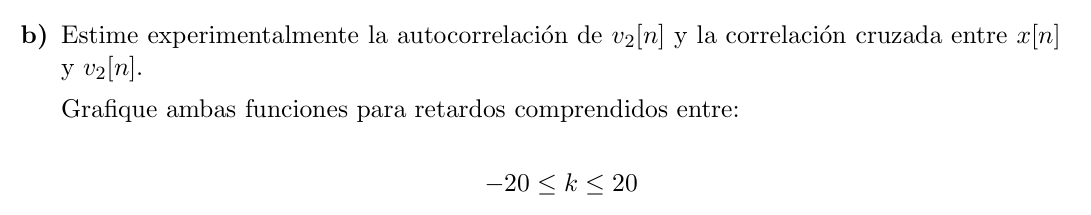

In [14]:
def autocorr(s, kmax):
    N = len(s)
    r = np.zeros(2 * kmax + 1)
    ks = np.arange(-kmax, kmax + 1)
    for i, k in enumerate(ks):
        if k >= 0:
            r[i] = np.sum(s[:N - k] * s[k:]) / N
        else:
            r[i] = np.sum(s[-k:] * s[:N + k]) / N
    return ks, r

def crosscorr(x, y, kmax):
    """r_xy[k] = E[x[n] y[n+k]] (sesgado)."""
    N = len(x)
    r = np.zeros(2 * kmax + 1)
    ks = np.arange(-kmax, kmax + 1)
    for i, k in enumerate(ks):
        if k >= 0:
            r[i] = np.sum(x[:N - k] * y[k:]) / N
        else:
            r[i] = np.sum(x[-k:] * y[:N + k]) / N
    return ks, r

kmax = 20
ks, rv2v2 = autocorr(v2, kmax)
_,  rxv2  = crosscorr(x, v2, kmax)

print(f"r_v2v2[0] = {rv2v2[kmax]:.4f}")
print(f"r_xv2[0]  = {rxv2[kmax]:.4f}")

r_v2v2[0] = 1.1494
r_xv2[0]  = 1.1893


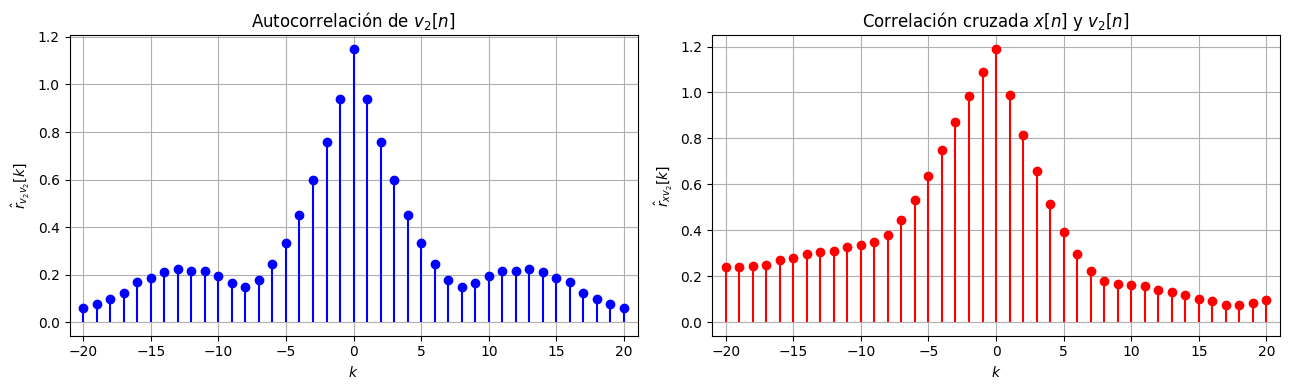

In [15]:
fig, axes = plt.subplots(1, 2, figsize=[13, 4])

axes[0].stem(ks, rv2v2, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('$k$')
axes[0].set_ylabel('$\\hat{r}_{v_2 v_2}[k]$')
axes[0].set_title('Autocorrelación de $v_2[n]$')
axes[0].grid(True)
axes[0].set_xlim([-kmax - 1, kmax + 1])

axes[1].stem(ks, rxv2, basefmt=" ", linefmt='r-', markerfmt='ro')
axes[1].set_xlabel('$k$')
axes[1].set_ylabel('$\\hat{r}_{x v_2}[k]$')
axes[1].set_title('Correlación cruzada $x[n]$ y $v_2[n]$')
axes[1].grid(True)
axes[1].set_xlim([-kmax - 1, kmax + 1])

plt.tight_layout()

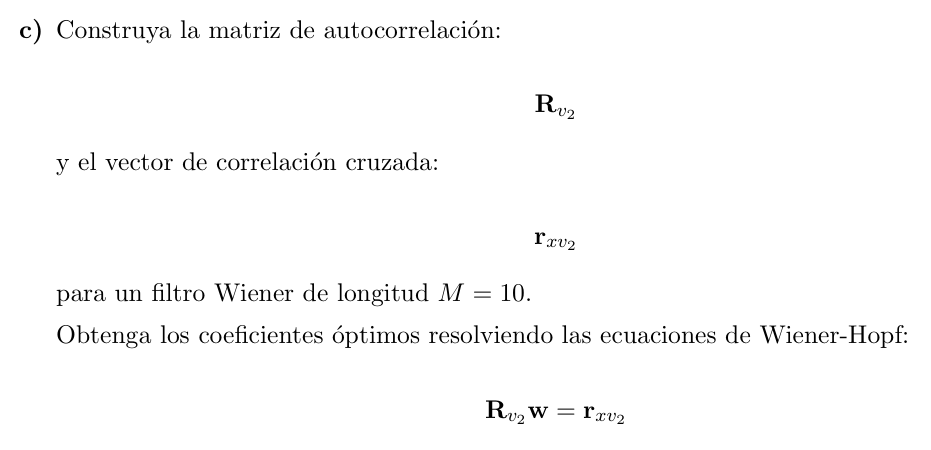

In [16]:
# Vector r_v2v2 centrado en k=0 para indexar por |i-j|
rv2_centered = rv2v2

# Matriz de autocorrelación R_v2 (M x M), Toeplitz
R_v2 = np.zeros((M, M))
for i in range(M):
    for j in range(M):
        R_v2[i, j] = rv2_centered[kmax + abs(i - j)]

# Vector de correlación cruzada r_xv2 (M x 1)
# r_xv2[i] = r_xv2[i]  (retardo no negativo)
r_xv2 = rxv2[kmax:kmax + M].reshape(-1, 1)

print(f"Dimensiones R_v2 : {R_v2.shape}")
print(f"Dimensiones r_xv2: {r_xv2.shape}")

Dimensiones R_v2 : (10, 10)
Dimensiones r_xv2: (10, 1)


In [17]:
# Solución del sistema de Wiener-Hopf
w_opt = np.linalg.solve(R_v2, r_xv2).flatten()

print("Coeficientes óptimos del filtro Wiener:")
for i, wi in enumerate(w_opt):
    print(f"  w[{i:2d}] = {wi:+.6f}")

Coeficientes óptimos del filtro Wiener:
  w[ 0] = +1.007622
  w[ 1] = +0.013513
  w[ 2] = +0.008200
  w[ 3] = +0.002664
  w[ 4] = +0.011610
  w[ 5] = +0.010592
  w[ 6] = +0.011690
  w[ 7] = +0.023354
  w[ 8] = +0.030919
  w[ 9] = -0.058657


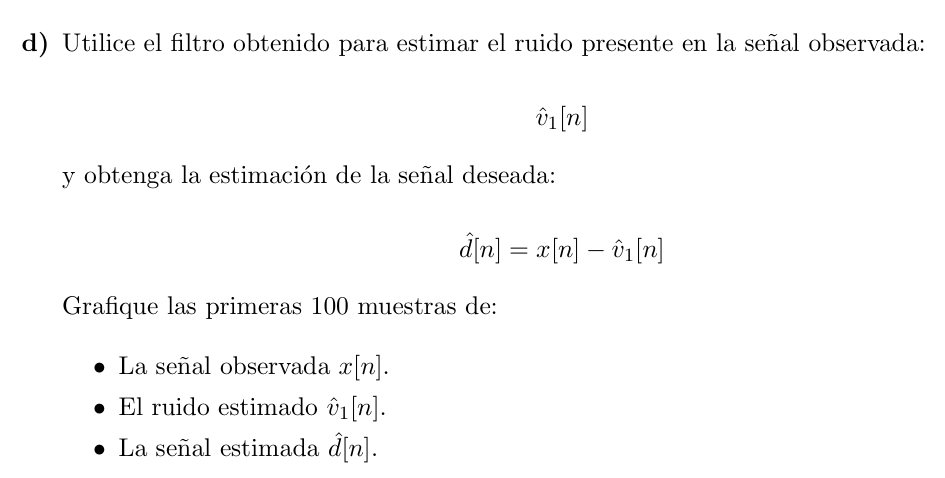

In [18]:
# Filtrado Wiener
v1_hat = signal.lfilter(w_opt, [1.0], v2)

# Estimación de la señal deseada
d_hat = x - v1_hat

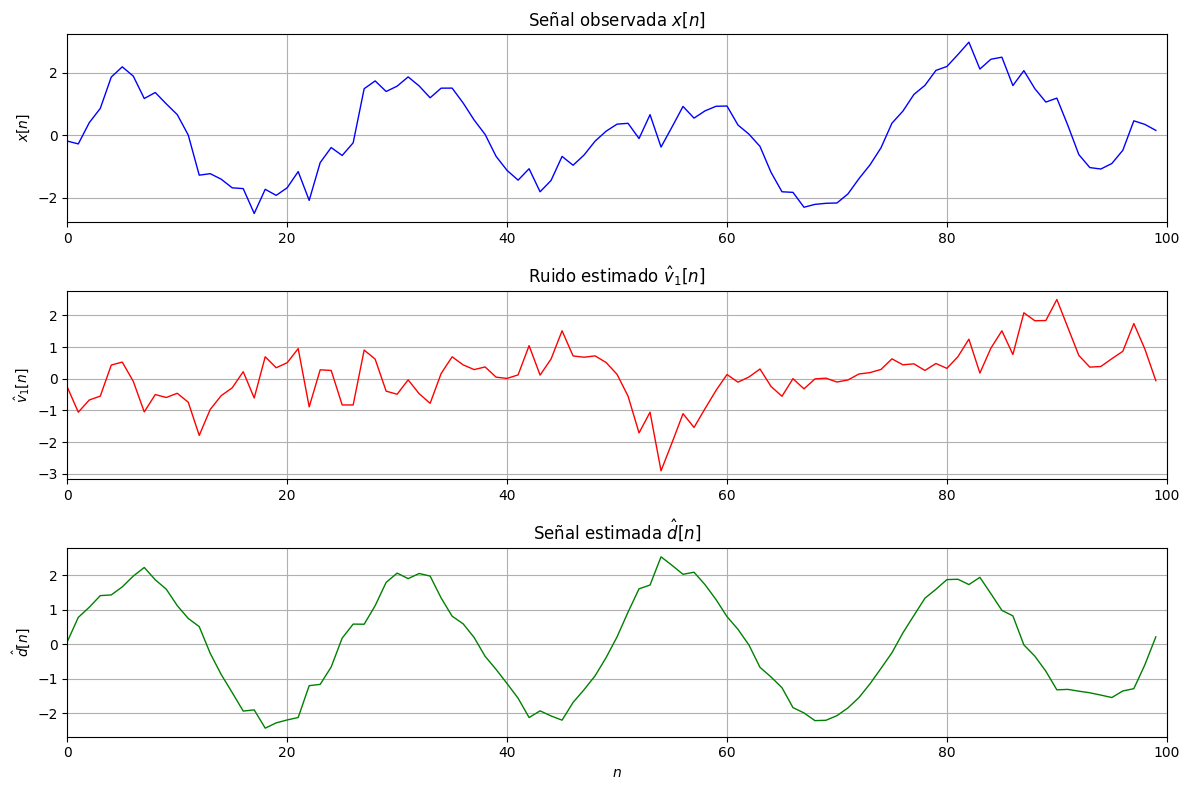

In [19]:
fig, axes = plt.subplots(3, 1, figsize=[12, 8])

axes[0].plot(n[:100], x[:100], 'b', linewidth=1.0)
axes[0].set_ylabel('$x[n]$')
axes[0].set_title('Señal observada $x[n]$')
axes[0].grid(True)
axes[0].set_xlim([0, 100])

axes[1].plot(n[:100], v1_hat[:100], 'r', linewidth=1.0)
axes[1].set_ylabel('$\\hat{v}_1[n]$')
axes[1].set_title('Ruido estimado $\\hat{v}_1[n]$')
axes[1].grid(True)
axes[1].set_xlim([0, 100])

axes[2].plot(n[:100], d_hat[:100], 'g', linewidth=1.0)
axes[2].set_xlabel('$n$')
axes[2].set_ylabel('$\\hat{d}[n]$')
axes[2].set_title('Señal estimada $\\hat{d}[n]$')
axes[2].grid(True)
axes[2].set_xlim([0, 100])

plt.tight_layout()

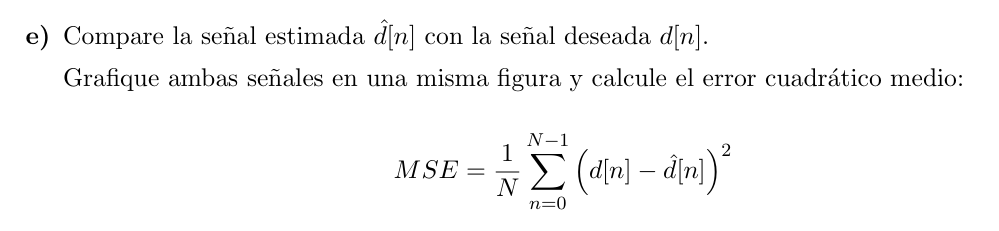

In [20]:
MSE = np.mean((d - d_hat) ** 2)
print(f"Error cuadrático medio: MSE = {MSE:.6f}")

Error cuadrático medio: MSE = 0.135495


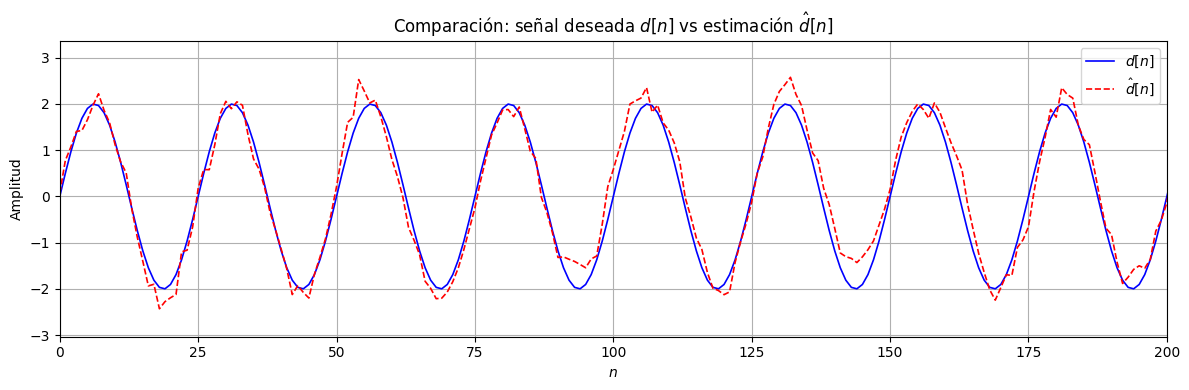

In [21]:
plt.figure(figsize=[12, 4])
plt.plot(n, d, 'b', linewidth=1.2, label='$d[n]$')
plt.plot(n, d_hat, 'r--', linewidth=1.2, label='$\\hat{d}[n]$')
plt.xlabel('$n$')
plt.ylabel('Amplitud')
plt.title('Comparación: señal deseada $d[n]$ vs estimación $\\hat{d}[n]$')
plt.legend()
plt.grid(True)
plt.xlim([0, 200])
plt.tight_layout()

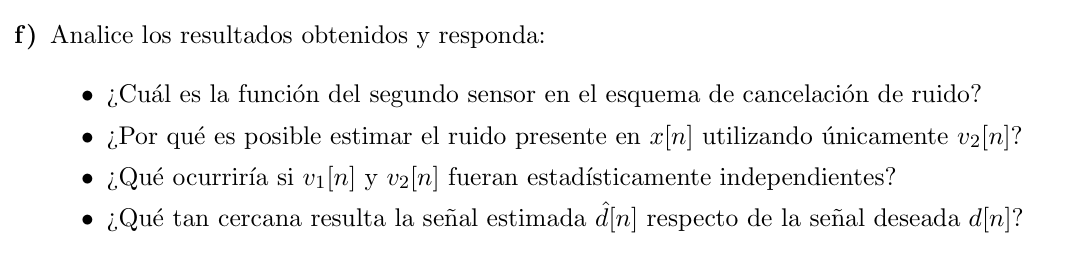

**Análisis de resultados.**

- El sensor que mide $v_2[n]$ proporciona una referencia del ruido presente en $x[n]$. Como $v_1[n]$ y $v_2[n]$ se generan a partir del mismo ruido blanco $w[n]$ (filtrado con coeficientes AR(1) distintos), están estadísticamente correlacionados.
- ¿Por qué es posible estimar $v_1[n]$ a partir de $v_2[n]$? 

  Porque ambos ruidos comparten una parte común ($w[n]$) y, por tanto, $r_{v_1 v_2}[k] \neq 0$.
  El filtro Wiener aprovecha esa correlación para reconstruir $\hat{v}_1[n]$ como combinación lineal de muestras pasadas y presentes de $v_2[n]$.
- ¿Qué pasaría si $v_1[n]$ y $v_2[n]$ fueran independientes? 

  Entonces $\mathbf{r}_{xv_2} = \mathbf{r}_{v_1 v_2} = \mathbf{0}$, la solución óptima sería $\mathbf{w} = \mathbf{0}$, y $\hat{d}[n] = x[n]$: el filtro no aporta mejora alguna.
- ¿Qué tan cercana es $\hat{d}[n]$ respecto a $d[n]$? 

  El MSE observado debe ser muy inferior a la varianza del ruido $v_1[n]$, lo que demuestra que el esquema Wiener logra una cancelación significativa. La cercanía depende del grado de correlación entre $v_1[n]$ y $v_2[n]$: cuanto más parecidos los coeficientes AR (en este caso 0.9 y 0.8), mejor será la estimación.